In [8]:
import jupyter_utils as ju
import straindesign as sd
base_dir = Path.home() / "Documents" / "PhD" / "10-19 Research" / "11 Data" / "11.09_Models"
#model = ju.load_model(base_dir,"Experiment", "250723_iABA974_BLG.sbml")
model = ju.load_model(base_dir,"Experiment", "250620_iABA974.sbml")

INFO:cobra.core.model:The current solver interface glpk doesn't support setting the optimality tolerance.


In [9]:
model.add_boundary(model.metabolites.get_by_id('bhb_c'), type='sink',lb=0.0, ub=1000)

Reaction identifier,SK_bhb_c
Name,(R)-3-Hydroxybutanoate sink
Memory address,0x158fd595f70
Stoichiometry,bhb_c --> (R)-3-Hydroxybutanoate -->
GPR,
Lower bound,0.0
Upper bound,1000


In [18]:
model.objective = "SK_bhb_c"


In [19]:
model.summary()

INFO:cobra.summary.model_summary:Generating new parsimonious flux distribution.


Metabolite,Reaction,Flux,C-Number,C-Flux
co2_e,EX_co2_e,2.47,1,100.00%
h2_e,EX_h2_e,19.4,0,0.00%
o2_e,EX_o2_e,7.075,0,0.00%
Metabolite,Reaction,Flux,C-Number,C-Flux
h2o_e,EX_h2o_e,-17.24,0,0.00%
bhb_c,SK_bhb_c,-0.6175,4,100.00%


This notebook will mainly use the strain design toolbox

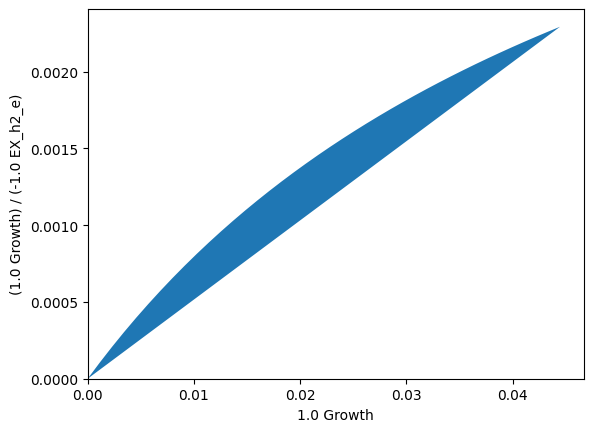

([[0.0, np.float64(0.0)],
  [0.001140353076923077, np.float64(5.8782e-05)],
  [0.002280706153846154, np.float64(0.000117563)],
  [0.003421059230769231, np.float64(0.000176344)],
  [0.004561412307692308, np.float64(0.000235125)],
  [0.005701765384615386, np.float64(0.000293906)],
  [0.006842118461538462, np.float64(0.000352687)],
  [0.007982471538461539, np.float64(0.000411468)],
  [0.009122824615384616, np.float64(0.000470249)],
  [0.010263177692307694, np.float64(0.00052903)],
  [0.011403530769230771, np.float64(0.000587811)],
  [0.012543883846153847, np.float64(0.000646592)],
  [0.013684236923076925, np.float64(0.000705374)],
  [0.014824590000000002, np.float64(0.000764155)],
  [0.015964943076923078, np.float64(0.000822936)],
  [0.017105296153846157, np.float64(0.000881717)],
  [0.018245649230769233, np.float64(0.000940498)],
  [0.01938600230769231, np.float64(0.000999279)],
  [0.020526355384615388, np.float64(0.00105806)],
  [0.021666708461538463, np.float64(0.001116841)],
  [0.0228

In [ ]:
sd.plot_flux_space(model,('Growth',('Growth','-EX_h2_e')),
                   constraints='-EX_o2_e <= 9')

In [13]:
ju.print_reaction_details(model, 'EX_h2_e')
#sd.plot_flux_space(model,('Growth',('Growth','-EX_co2_e')))



Reaction ID   : EX_h2_e
Name          : EX_h2_e
Equation      : h2_e <-- 
Lower Bound   : -19.4
Upper Bound   : 0.0

Metabolites and Stoichiometry:
 - h2_e           :   -1.0  Name: Hydrogen                                           Charge:   0  Formula: H2

Sum of Charge Balance: 0.0

Associated Genes:
 - None


In [3]:
model.summary()

Metabolite,Reaction,Flux,C-Number,C-Flux
ca2_e,EX_ca2_e,0.000185,0,0.00%
cl_e,EX_cl_e,0.000185,0,0.00%
co2_e,EX_co2_e,1.785,1,100.00%
cobalt2_e,EX_cobalt2_e,8.967E-07,0,0.00%
cu2_e,EX_cu2_e,0.000252,0,0.00%
fe2_e,EX_fe2_e,0.0005412,0,0.00%
h2_e,EX_h2_e,17.99,0,0.00%
k_e,EX_k_e,0.006938,0,0.00%
mg2_e,EX_mg2_e,0.0003084,0,0.00%
mn2_e,EX_mn2_e,2.458E-05,0,0.00%


In [2]:
model.objective = 'Growth'
model.optimize()

,fluxes,reduced_costs
EX_25dkglcn_e,0.000000,-2.025297e-01
EX_2ameph_e,0.000000,-5.786563e-02
EX_2m35mdntha_e,0.000000,0.000000e+00
EX_2pglyc_e,0.000000,-5.786563e-02
EX_34dhbz_e,0.000000,-1.499246e-01
...,...,...
CYTHYD,0.000000,-7.101691e-02
Growth,0.037363,-1.500844e-15
BLG_x1_production,0.000000,-1.773062e-01
BLG_x1t,0.000000,0.000000e+00


In [21]:
module_optcouple = sd.SDModule(model,sd.names.OPTCOUPLE,
                              inner_objective='Growth',
                              prod_id='SK_bhb_c',
                              min_gcp=0.3)

import logging
logging.basicConfig(level=logging.INFO)
## Compute strain designs
# allow all gene knockouts except for spontanuos
gko_cost = {g.name:1 for g in model.genes}
#gko_cost.pop('s0001')
# possible knockout of O2
ko_cost = {'EX_o2_e': 1}

sols = sd.compute_strain_designs(model,
                                 sd_modules = module_optcouple,
                                 max_solutions = 1,
                                 max_cost = 15,
                                 gko_cost = gko_cost,
                                 ko_cost = ko_cost,
                                 solution_approach = sd.names.BEST)
# Print solution
print(f"One compressed solution with cost {sols.sd_cost[0]} found and "+\
      f"expanded to {len(sols.gene_sd)} solutions in the uncompressed netork.")
print(f"Example intervention set: {['+'+s if v>0 else '-'+s for s,v in sols.gene_sd[0].items() if v!=0]}")

import matplotlib.pyplot as plt
# Wild-type plot
datapoints, triang, plot1 = sd.plot_flux_space(model,
                                               ('Growth','SK_bhb_c'),
                                               show=False);

# OptKnock design plot
interventions = [[{s:1.0},'=',0.0] for s,v in sols.reaction_sd[0].items() if v < 1]
_,          _,      plot3 = sd.plot_flux_space(model,
                                               ('Growth','SK_bhb_c'),
                                               # The sign of the glucose exchange reaction is flipped since
                                               # reaction is defined in the direction of secretion.
                                               constraints=interventions,
                                               show=False);
plot3.set_facecolor('#FFC000')
plot3.set_edgecolor('#FFC000')
# adjust axes limits and show plot
plot3.axes.set_xlim(0, 1.05*max([a[0] for a in datapoints]))
plot3.axes.set_ylim(0, 1.05*max([a[1] for a in datapoints]))
plt.show()

INFO:root:Preparing strain design computation.
INFO:root:  Using random seed 42231
INFO:root:  Using glpk for solving LPs during preprocessing.
INFO:root:  FVA to identify blocked reactions and irreversibilities.
INFO:root:  FVA(s) to identify essential reactions.
INFO:root:Preprocessing GPR rules (974 genes, 1608 gpr rules).


KeyboardInterrupt: 